In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/home/sneh.ratanpara@simform.dom/Sneh Ratanpara Learning/Python Programming/HR_Dataset_Cleaning/Dataset/archive(2)/train.csv')
df_test = pd.read_csv('/home/sneh.ratanpara@simform.dom/Sneh Ratanpara Learning/Python Programming/HR_Dataset_Cleaning/Dataset/archive(2)/test.csv')

In [3]:
df.sample(5)

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
20396,1909,Technology,region_27,Bachelor's,f,sourcing,1,25,1.0,3,0,79,0
32197,53329,Procurement,region_14,Master's & above,m,other,1,37,3.0,2,0,65,0
15649,24701,Operations,region_32,Bachelor's,m,sourcing,1,38,3.0,6,0,59,0
34963,23319,Procurement,region_32,Bachelor's,m,sourcing,1,27,3.0,4,0,68,0
27626,8613,Technology,region_24,Bachelor's,f,other,1,29,1.0,2,0,77,0


In [4]:
df_test.sample(5)

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score
19069,1463,Sales & Marketing,region_2,Master's & above,f,sourcing,1,59,1.0,4,0,55
9990,26054,Sales & Marketing,region_7,Master's & above,m,sourcing,1,38,4.0,4,0,50
7066,9545,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,29,NaN,1,0,55
20433,21495,Sales & Marketing,region_13,Master's & above,m,sourcing,1,36,3.0,7,0,50
3546,31091,Operations,region_20,Bachelor's,m,other,1,33,2.0,8,0,58


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54808 entries, 0 to 54807
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   employee_id           54808 non-null  int64  
 1   department            54808 non-null  object 
 2   region                54808 non-null  object 
 3   education             52399 non-null  object 
 4   gender                54808 non-null  object 
 5   recruitment_channel   54808 non-null  object 
 6   no_of_trainings       54808 non-null  int64  
 7   age                   54808 non-null  int64  
 8   previous_year_rating  50684 non-null  float64
 9   length_of_service     54808 non-null  int64  
 10  awards_won?           54808 non-null  int64  
 11  avg_training_score    54808 non-null  int64  
 12  is_promoted           54808 non-null  int64  
dtypes: float64(1), int64(7), object(5)
memory usage: 5.4+ MB


# Observation
- education and previous year rating have null values so we need to handle it

In [6]:
df.describe()

,employee_id,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
count,54808.000000,54808.000000,54808.000000,50684.000000,54808.000000,54808.000000,54808.000000,54808.000000
mean,39195.830627,1.253011,34.803915,3.329256,5.865512,0.023172,63.386750,0.085170
std,22586.581449,0.609264,7.660169,1.259993,4.265094,0.150450,13.371559,0.279137
min,1.000000,1.000000,20.000000,1.000000,1.000000,0.000000,39.000000,0.000000
25%,19669.750000,1.000000,29.000000,3.000000,3.000000,0.000000,51.000000,0.000000
50%,39225.500000,1.000000,33.000000,3.000000,5.000000,0.000000,60.000000,0.000000
75%,58730.500000,1.000000,39.000000,4.000000,7.000000,0.000000,76.000000,0.000000
max,78298.000000,10.000000,60.000000,5.000000,37.000000,1.000000,99.000000,1.000000


# Observation
- Mean of Age is 34 so people are young in job
- less than 3% employee have won the awards
- around 8.5% people got promoted 

In [7]:
df.nunique()

employee_id             54808
department                  9
region                     34
education                   3
gender                      2
recruitment_channel         3
no_of_trainings            10
age                        41
previous_year_rating        5
length_of_service          35
awards_won?                 2
avg_training_score         61
is_promoted                 2
dtype: int64

# Observation

- there are three types in education and 2 in gender we can use one hot encoding to encode it so we can use in our model training
- and for previous year rating we can use label encoding before it is ordinal
- 

In [8]:
df.isnull().sum()

employee_id                0
department                 0
region                     0
education               2409
gender                     0
recruitment_channel        0
no_of_trainings            0
age                        0
previous_year_rating    4124
length_of_service          0
awards_won?                0
avg_training_score         0
is_promoted                0
dtype: int64

In [9]:
df[df['education'].isna()]

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
10,29934,Technology,region_23,NaN,m,sourcing,1,30,NaN,1,0,77,0
21,33332,Operations,region_15,NaN,m,sourcing,1,41,4.0,11,0,57,0
32,35465,Sales & Marketing,region_7,NaN,f,sourcing,1,24,1.0,2,0,48,0
43,17423,Sales & Marketing,region_2,NaN,m,other,3,24,2.0,2,0,48,0
82,66013,Sales & Marketing,region_2,NaN,m,sourcing,2,25,3.0,2,0,53,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
54692,14821,Sales & Marketing,region_2,NaN,f,sourcing,1,35,3.0,7,0,53,0
54717,7684,Analytics,region_2,NaN,m,sourcing,1,32,3.0,4,0,86,0
54729,1797,HR,region_2,NaN,f,other,1,28,3.0,2,0,53,0
54742,38935,Sales & Marketing,region_31,NaN,m,other,1,28,4.0,3,0,47,0


In [10]:
df[df['previous_year_rating'].isna()]

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,awards_won?,avg_training_score,is_promoted
10,29934,Technology,region_23,NaN,m,sourcing,1,30,NaN,1,0,77,0
23,71177,Procurement,region_5,Bachelor's,m,other,1,27,NaN,1,0,70,0
29,74759,Sales & Marketing,region_4,Bachelor's,m,sourcing,1,26,NaN,1,0,44,0
56,45709,Sales & Marketing,region_31,Bachelor's,f,other,1,29,NaN,1,0,49,0
58,26599,Sales & Marketing,region_16,Bachelor's,m,other,2,27,NaN,1,0,47,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
54703,74615,R&D,region_31,Bachelor's,m,sourcing,1,30,NaN,1,0,88,0
54734,11685,Operations,region_15,Bachelor's,m,sourcing,1,31,NaN,1,0,56,1
54746,10546,Finance,region_6,Bachelor's,m,other,1,28,NaN,1,0,61,0
54773,37919,Finance,region_2,Bachelor's,m,other,1,23,NaN,1,0,61,0


# observation

- We can fill missing values of education with mode because it is categorical values
- For rating we can fill with median because it will give the middle values if we use mean then it will fill with 3.33 which is not valid rating

In [11]:
df.isnull().mean()*100

employee_id             0.000000
department              0.000000
region                  0.000000
education               4.395344
gender                  0.000000
recruitment_channel     0.000000
no_of_trainings         0.000000
age                     0.000000
previous_year_rating    7.524449
length_of_service       0.000000
awards_won?             0.000000
avg_training_score      0.000000
is_promoted             0.000000
dtype: float64

# Observation
- Missing values are only in two column and are relatively less
- missing values in education is less than 5 % so we can analysis and fill that values with mean or median
- missing values in previous year rating is more than 5% and it depends on other column too so we can groupby column to check how other columns affect this by this we can fill missing values

<Axes: >

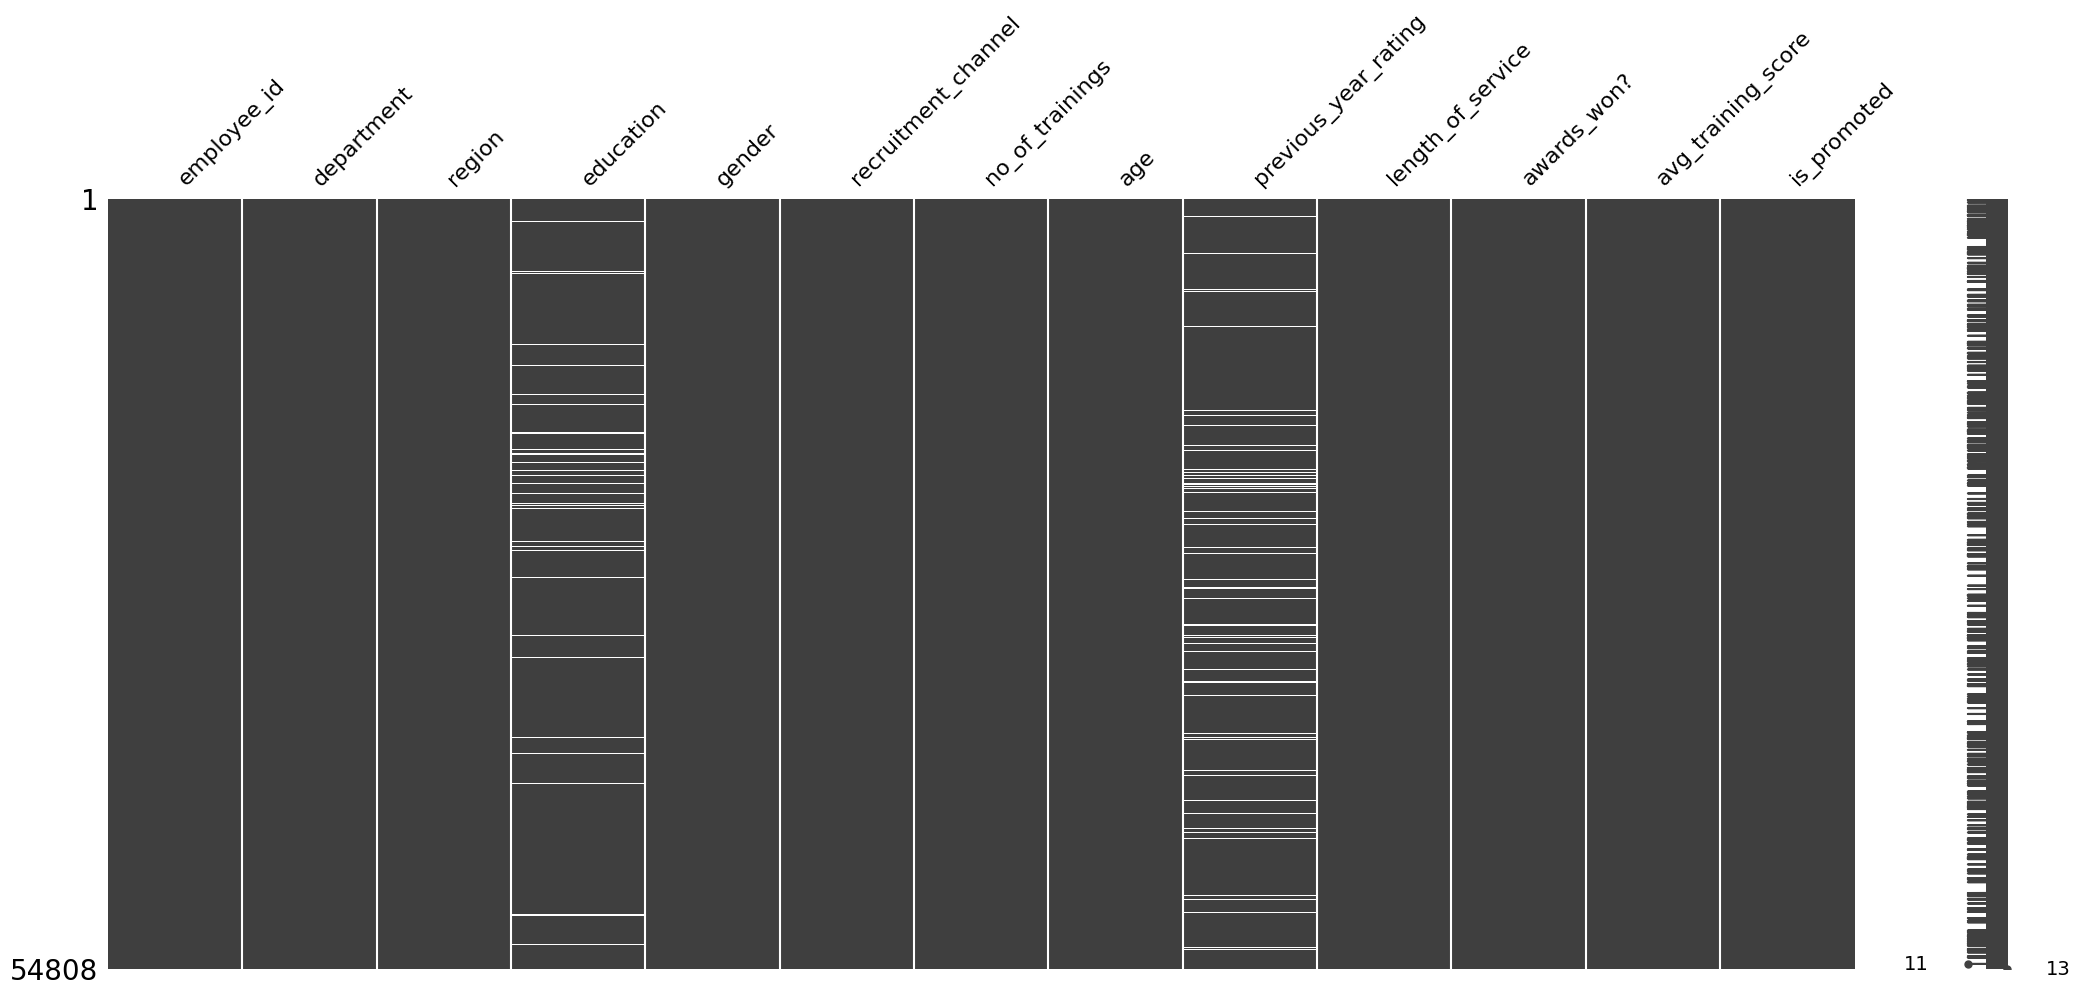

In [12]:
import missingno as msno
msno.matrix(df)

## Observation

- white line show missing values in education and previous year rating

In [13]:
df['previous_year_rating'].isnull().sum()

np.int64(4124)

In [14]:
df[df['previous_year_rating'].isnull()]['education'].isnull().sum() 

np.int64(385)

# Observation
- Only 385 rows in which both previous year ratingf and education are null so we can say that it is not dependent columns

<Axes: xlabel='is_promoted', ylabel='count'>

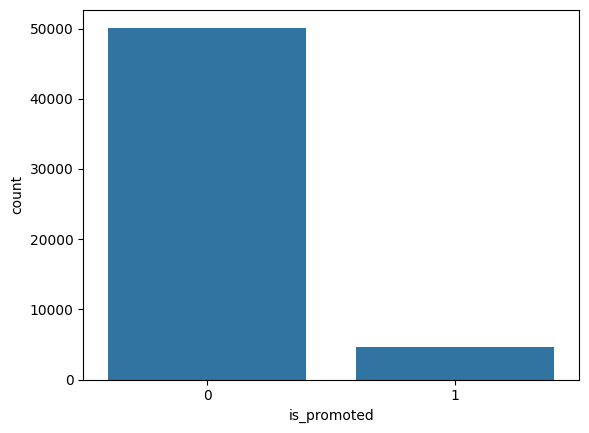

In [15]:
sns.countplot(x='is_promoted', data=df)

# Observation
- There are only 8.5% people got promoted i think the dataset is imbalance so in future we need to balance this dataset

array([[<Axes: title={'center': 'age'}>,
        <Axes: title={'center': 'avg_training_score'}>],
       [<Axes: title={'center': 'length_of_service'}>,
        <Axes: title={'center': 'previous_year_rating'}>]], dtype=object)

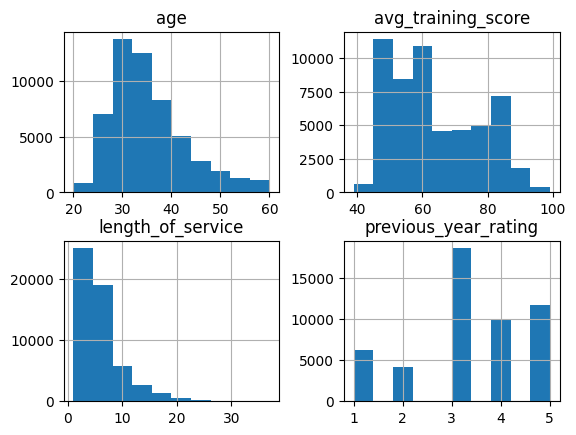

In [16]:
df[['age', 'avg_training_score', 'length_of_service', 'previous_year_rating']].hist()

# Observation

**age**
- Distribution is right-skewed — majority of employees are between 25–35 years old
- We can use Log tranform to transform it into normal form


**avg_training_score**
- Shows a bimodal distribution — two peaks, one around 45–50 and another around 55–60
- There's also a small group scoring 80–99 — these are likely the high performers who get promoted



**length_of_service**
- Heavily right-skewed — most employees have only 1–5 years of service
- Very few employees with 20+ years 
- We can use Log tranform to transform it into normal form



**previous_year_rating**
- Ratings are discrete (1 to 5) so histogram looks like a bar chart
- Rating 3 and 5 are most common — most employees are average or high performers
- Rating 2 is the least common — very few poor performers
- Bimodal tendency between 3 and 5

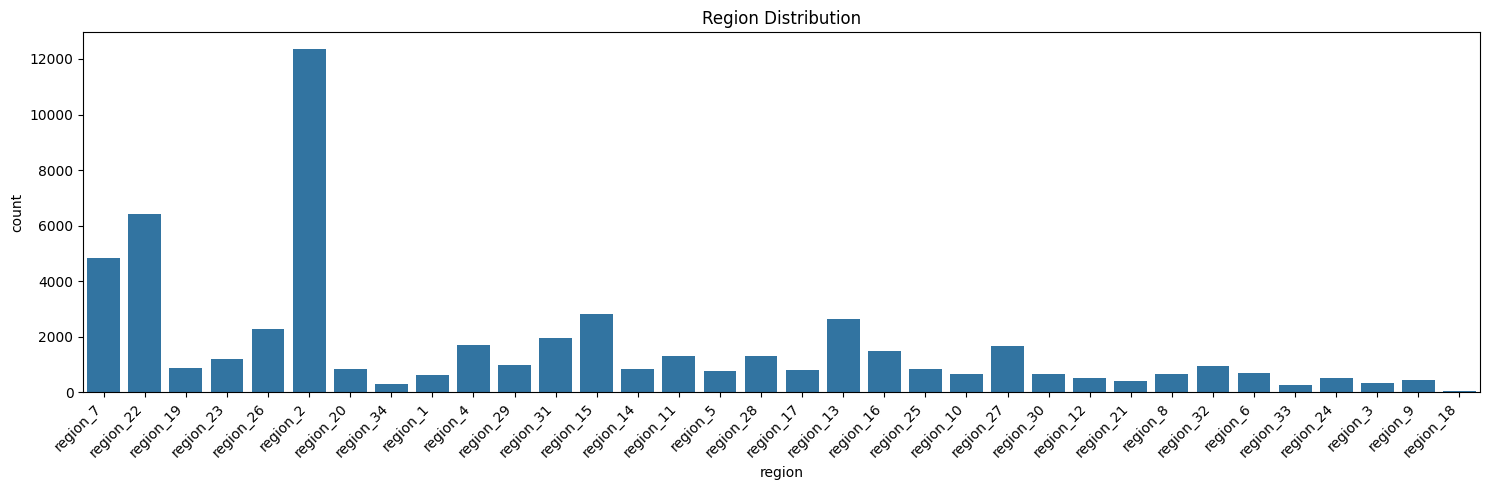

In [17]:
plt.figure(figsize=(15, 5))
sns.countplot(x='region', data=df)
plt.xticks(rotation=45, ha='right')
plt.title('Region Distribution')
plt.tight_layout()
plt.show()

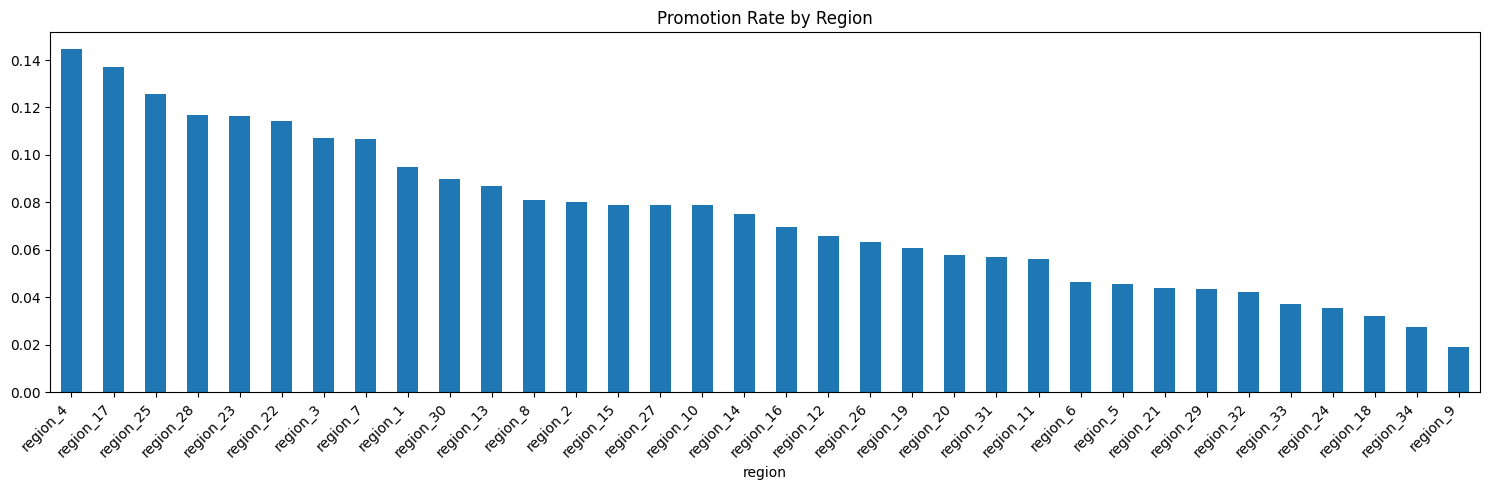

In [30]:
df.groupby('region')['is_promoted'].mean().sort_values(ascending=False).plot(kind='bar', figsize=(15,5))
plt.title('Promotion Rate by Region')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## Observation
- this region column can not useful in model training so we can drop it

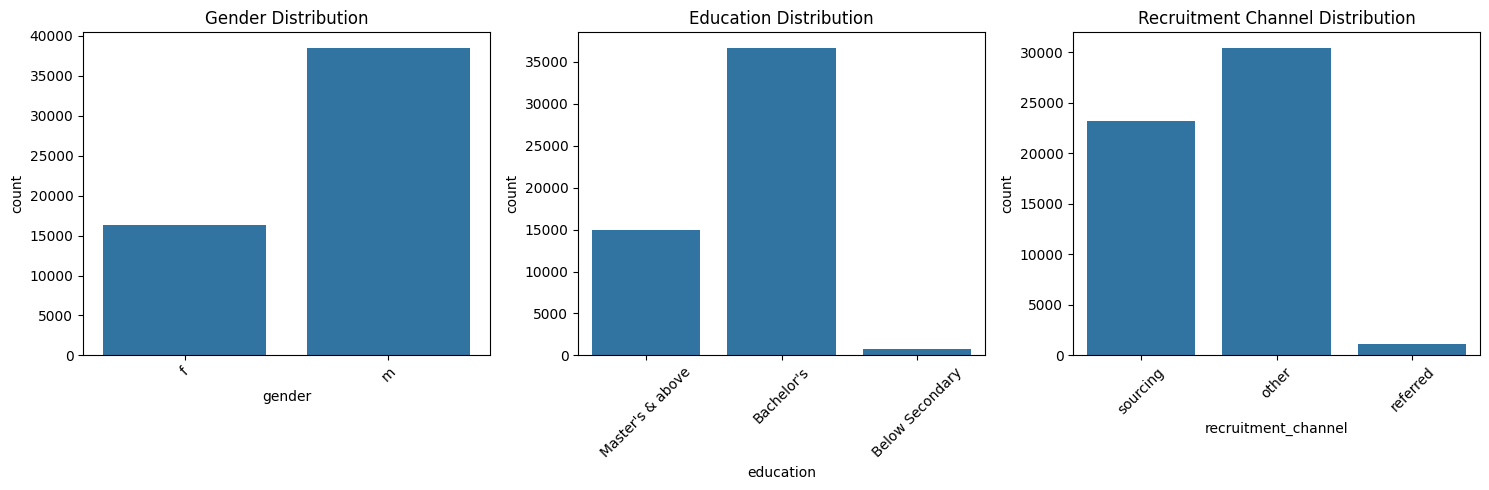

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.countplot(x='gender', data=df, ax=axes[0])
axes[0].set_title('Gender Distribution')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(x='education', data=df, ax=axes[1])
axes[1].set_title('Education Distribution')
axes[1].tick_params(axis='x', rotation=45)

sns.countplot(x='recruitment_channel', data=df, ax=axes[2])
axes[2].set_title('Recruitment Channel Distribution')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Observation 

**Gender Distribution**

- Dataset is heavily male dominated — males (~38,000) and females (~16,000)
- This raises a question — is promotion rate also biased towards males? Worth checking in bivariate
- Could indicate a gender imbalance in hiring within this company


**Education Distribution**

- Bachelors degree holders dominate with ~36,000 employees — roughly 65% of workforce
- Master's & above is second with ~15,000 employees
- Below Secondary is extremely rare — barely ~1,000 employees
- Most employees are well educated, which makes sense for a corporate environment


**Recruitment Channel Distribution**

- "Other" channel is the most common with ~30,000 employees — likely internal job postings or walk-ins
- Sourcing is second with ~23,000 — meaning recruiter/agency based hiring
- Referred is the least common


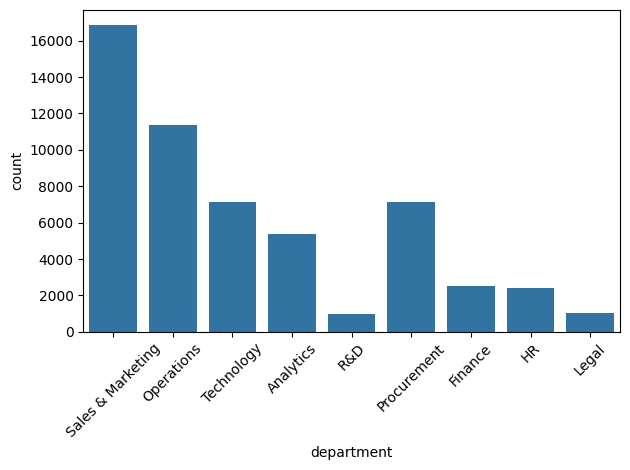

In [20]:
sns.countplot(x='department', data=df)
plt.xticks(rotation=45)  
plt.tight_layout()        
plt.show()

# Observation

- The dataset is heavily dominated by Sales & Marketing and Operations — these two alone make up nearly 50% of the data
- This imbalance in department size means the model might be biased towards predicting promotions based on Sales & Marketing patterns



In [21]:
skewness = df.select_dtypes(include='number').skew().sort_values(ascending=False)
print("Skewness of Numerical Columns:")
print(skewness)

Skewness of Numerical Columns:
awards_won?             6.338914
no_of_trainings         3.445434
is_promoted             2.972339
length_of_service       1.738061
age                     1.007432
avg_training_score      0.451908
employee_id            -0.003128
previous_year_rating   -0.310638
dtype: float64


## Observations

- **awards_won** (6.34) → Extremely right skewed, most employees have never won an award
- **no_of_trainings** (3.45) → Highly right skewed, most employees attend only 1 training
- **is_promoted** (2.97) → Highly skewed due to class imbalance (only 8.5% promoted)
- **length_of_service** (1.74) → Highly right skewed, most employees are relatively new
- **age** (1.00) → Moderately skewed, workforce is younger
- **avg_training_score** (0.45) → Slightly skewed, acceptable as is
- **employee_id** (-0.003) → Nearly zero, just an identifier, ignore
- **previous_year_rating** (-0.31) → Slightly left skewed, acceptable as is

## What We Can Do to Fix Skewness

- **Log Transformation** → for awards_won, no_of_trainings, length_of_service (highly skewed)
- **Square Root Transformation** → for age (moderately skewed)
- **Leave as is** → avg_training_score and previous_year_rating are acceptable
- **SMOTE** → for is_promoted (class imbalance, not a transformation issue)

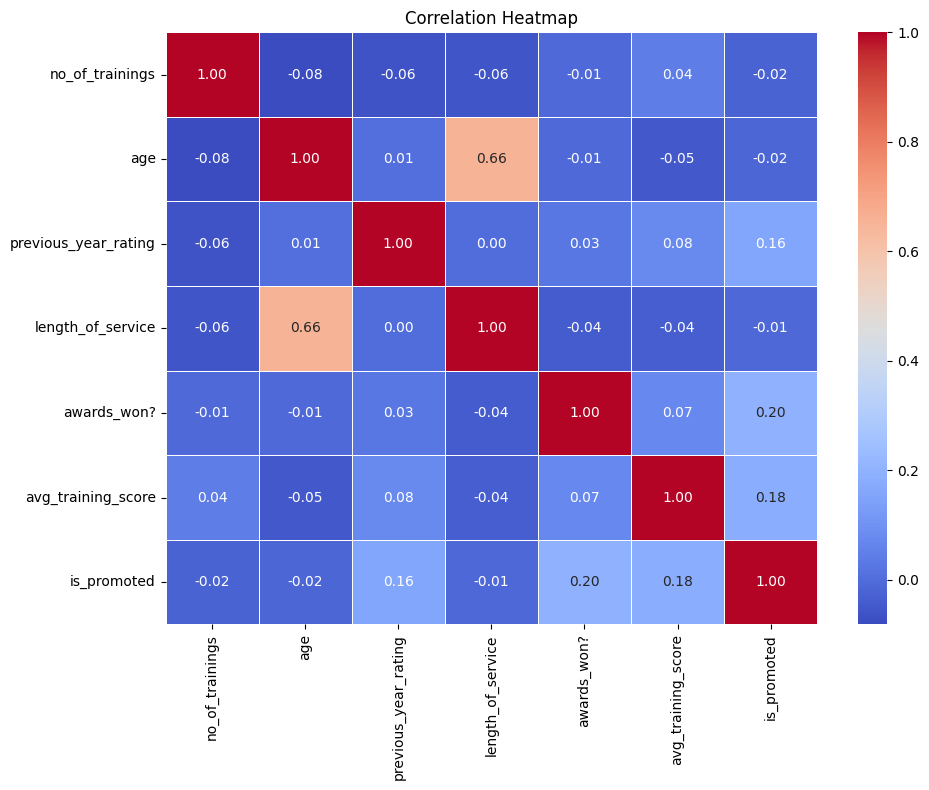

In [22]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include='number').drop(columns=['employee_id']).corr(), 
            annot=True,        
            cmap='coolwarm',     
            fmt='.2f',           
            linewidths=0.5)

plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

## Correlation Heatmap Observations

- **awards_won** has the highest relation with promotion (0.20) — 
  employees who won awards are more likely to get promoted

- **avg_training_score** is second (0.18) — 
  employees who score high in training have better chances of promotion

- **previous_year_rating** is third (0.16) — 
  employees with good past performance rating get promoted more

- **age and length_of_service** are strongly related to each other (0.66) — 
  this makes sense because older employees naturally have more years of experience, 
  we may need to drop one of them before building the model

- **no_of_trainings, age, length_of_service** have almost zero relation 
  with promotion — attending more trainings or being older does NOT 
  guarantee promotion

- Overall all correlations are weak — meaning NO single feature alone 
  can predict promotion, the model needs to look at ALL features together

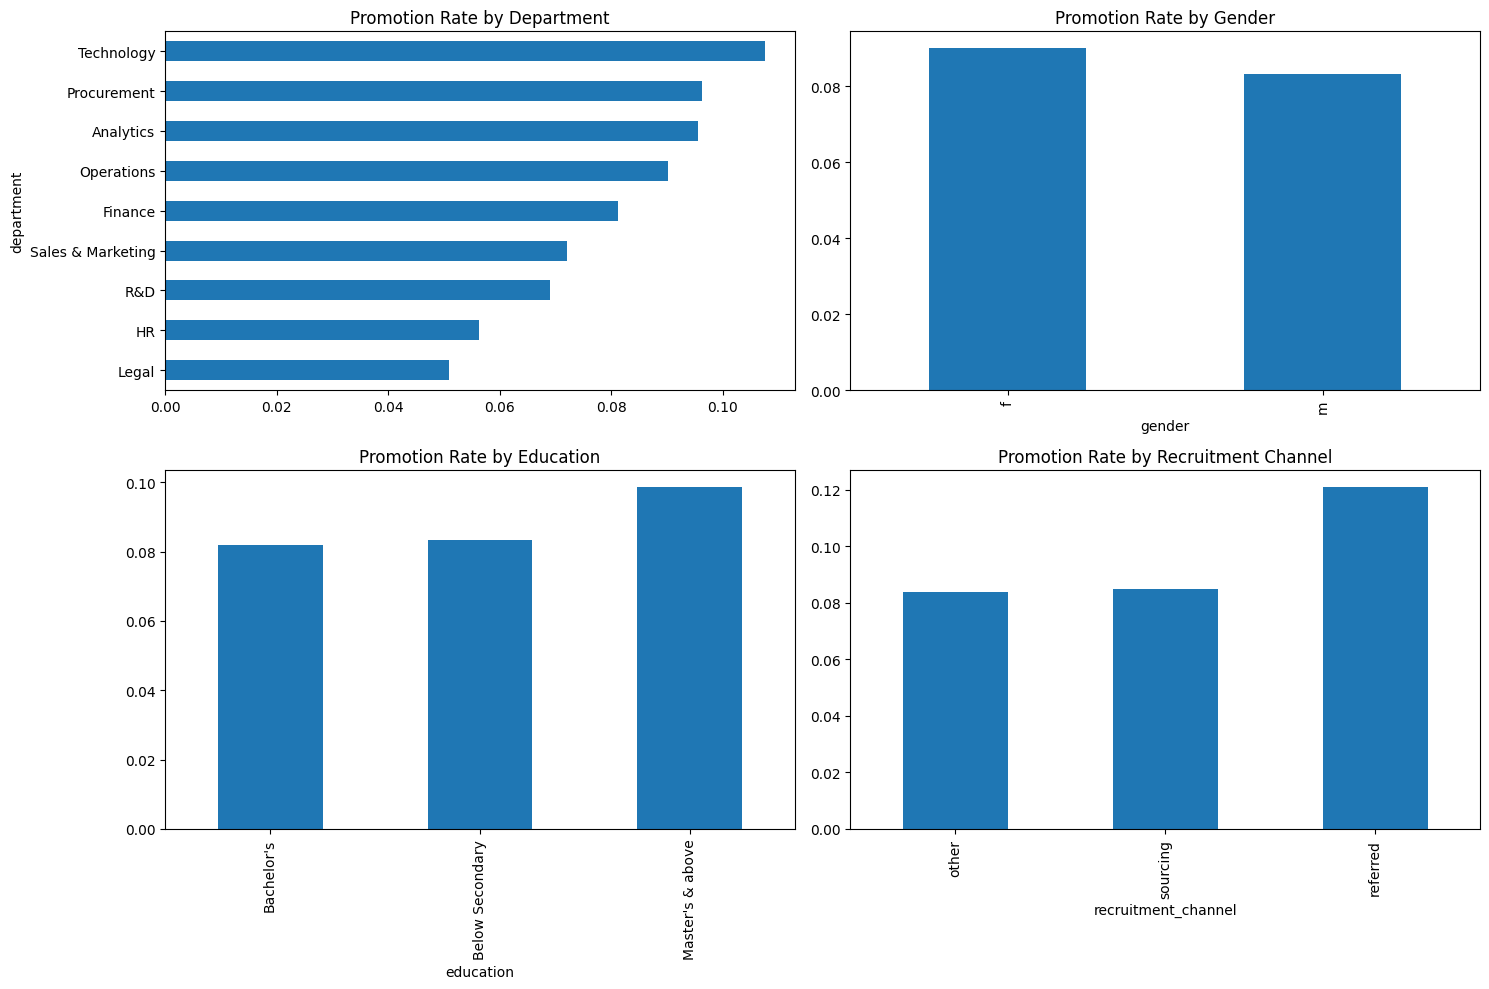

In [23]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Department vs Promotion
df.groupby('department')['is_promoted'].mean().sort_values().plot(
    kind='barh', ax=axes[0,0], title='Promotion Rate by Department')

# Gender vs Promotion
df.groupby('gender')['is_promoted'].mean().plot(
    kind='bar', ax=axes[0,1], title='Promotion Rate by Gender')

# Education vs Promotion
df.groupby('education')['is_promoted'].mean().sort_values().plot(
    kind='bar', ax=axes[1,0], title='Promotion Rate by Education')

# Recruitment Channel vs Promotion
df.groupby('recruitment_channel')['is_promoted'].mean().sort_values().plot(
    kind='bar', ax=axes[1,1], title='Promotion Rate by Recruitment Channel')

plt.tight_layout()
plt.show()

## Bivariate Analysis Observations

### Promotion Rate by Department
- **Technology** department has the highest promotion rate (~10%) — 
  employees in technology are most likely to get promoted
- **Legal** department has the lowest promotion rate (~6%) — 
  very few people get promoted here
- **Sales & Marketing** has a lower promotion rate despite being 
  the largest department — big size does not mean more promotions


### Promotion Rate by Gender
- **Females** have a slightly higher promotion rate than males
- But the difference is very small — gender does not play 
  a major role in deciding promotion in this company

### Promotion Rate by Education
- **Master's & above** employees have the highest promotion 
  rate (~10%) — higher education = better chance of promotion
- **Below Secondary** and **Bachelor's** have similar and 
  lower promotion rates (~8%)


### Promotion Rate by Recruitment Channel
- **Referred** employees have the highest promotion rate (~12%) — 
  employees who joined through referral perform better and 
  get promoted more
- **Other and Sourcing** channels have similar and lower 
  promotion rates (~8%)
- This suggests referred employees are higher quality hires

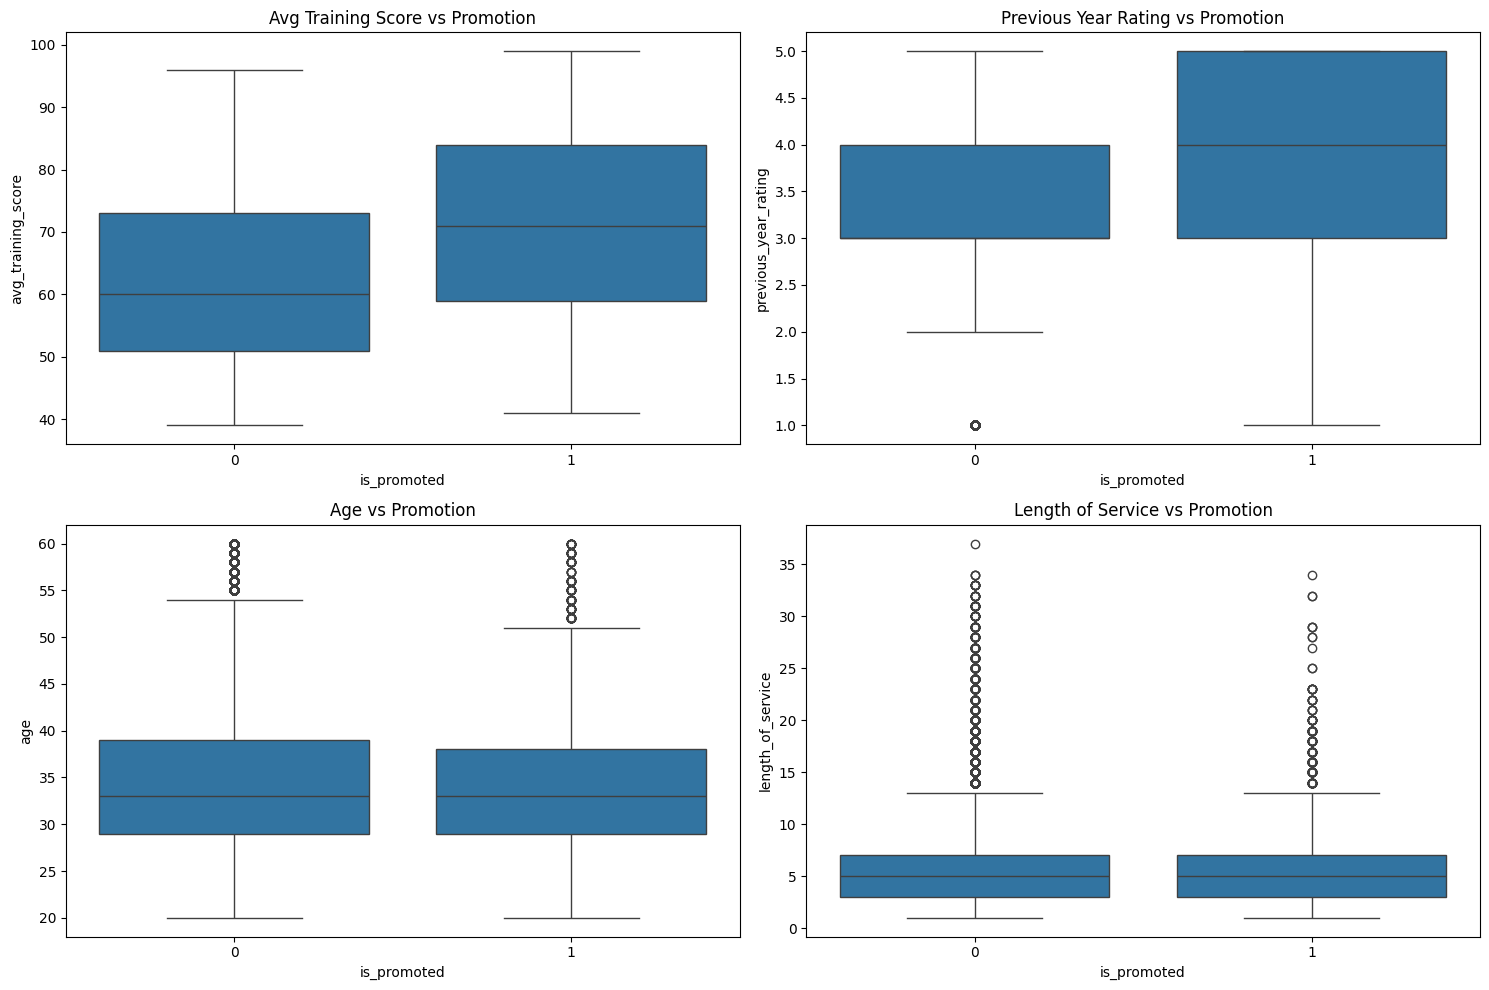

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Avg Training Score vs Promotion
sns.boxplot(x='is_promoted', y='avg_training_score', data=df, ax=axes[0,0])
axes[0,0].set_title('Avg Training Score vs Promotion')

# Previous Year Rating vs Promotion
sns.boxplot(x='is_promoted', y='previous_year_rating', data=df, ax=axes[0,1])
axes[0,1].set_title('Previous Year Rating vs Promotion')

# Age vs Promotion
sns.boxplot(x='is_promoted', y='age', data=df, ax=axes[1,0])
axes[1,0].set_title('Age vs Promotion')

# Length of Service vs Promotion
sns.boxplot(x='is_promoted', y='length_of_service', data=df, ax=axes[1,1])
axes[1,1].set_title('Length of Service vs Promotion')

plt.tight_layout()
plt.show()

## Numerical Features vs Promotion Observations

### Avg Training Score vs Promotion
- Employees who got promoted (1) have a clearly higher 
  training score (around 70-80) compared to those not 
  promoted (0) which is around 60
- This confirms that scoring high in training is a strong 
  signal for getting promoted
- The box for promoted employees is higher up — meaning 
  even their average performer scored better than 
  non-promoted employees

### Previous Year Rating vs Promotion
- Promoted employees (1) have a higher previous year 
  rating (mostly 4-5) compared to non-promoted (0) 
  which is around 3-4
- Good past performance clearly increases chances of promotion
- There is one outlier in non-promoted group with rating 1 — 
  meaning some very poor performers were also considered

### Age vs Promotion
- Promoted and non-promoted employees have almost 
  similar age range (around 30-40)
- Age does NOT play a major role in deciding promotion
- This matches our correlation value of -0.02 (nearly zero)
- There are some outliers above 55 in both groups

### Length of Service vs Promotion
- Both promoted and non-promoted employees have very 
  similar length of service (around 5 years)
- How long you have worked does NOT guarantee promotion
- Lots of outliers visible — some employees have worked 
  30+ years but still not promoted


### Overall Takeaway
- **Training score and previous year rating** are the most 
  important factors for promotion
- **Age and length of service** do not matter much 

In [25]:
# Awards won vs Promotion  
print(df.groupby('awards_won?')['is_promoted'].mean())

awards_won?
0    0.076749
1    0.440157
Name: is_promoted, dtype: float64


## Awards Won vs Promotion (Groupby Analysis)

- Employees who did **NOT win any award (0)** have a 
  promotion rate of only **7.6%**

- Employees who **won an award (1)** have a promotion 
  rate of **44%**

In [26]:
from scipy.stats import chi2_contingency

# Is gender related to promotion?
ct = pd.crosstab(df['gender'], df['is_promoted'])
chi2, p, dof, expected = chi2_contingency(ct)
print(f'p-value: {p}')

p-value: 0.009765091521176657


In [27]:
from scipy.stats import ttest_ind

# Is training score significantly different for promoted vs not?
promoted = df[df['is_promoted']==1]['avg_training_score']
not_promoted = df[df['is_promoted']==0]['avg_training_score']
t, p = ttest_ind(promoted, not_promoted)
print(f'p-value: {p}')

p-value: 0.0


## Hypothesis Testing Observations

### Chi-Square Test — Gender vs Promotion
- p-value = 0.009 (less than 0.05)
- This means the relationship between gender and 
  promotion is **REAL and not by chance**


### T-Test — Avg Training Score vs Promotion
- p-value = 0.0 (extremely less than 0.05)
- This is the strongest possible result — the difference 
  in training scores between promoted and non-promoted 
  employees is **100% real and not by chance**



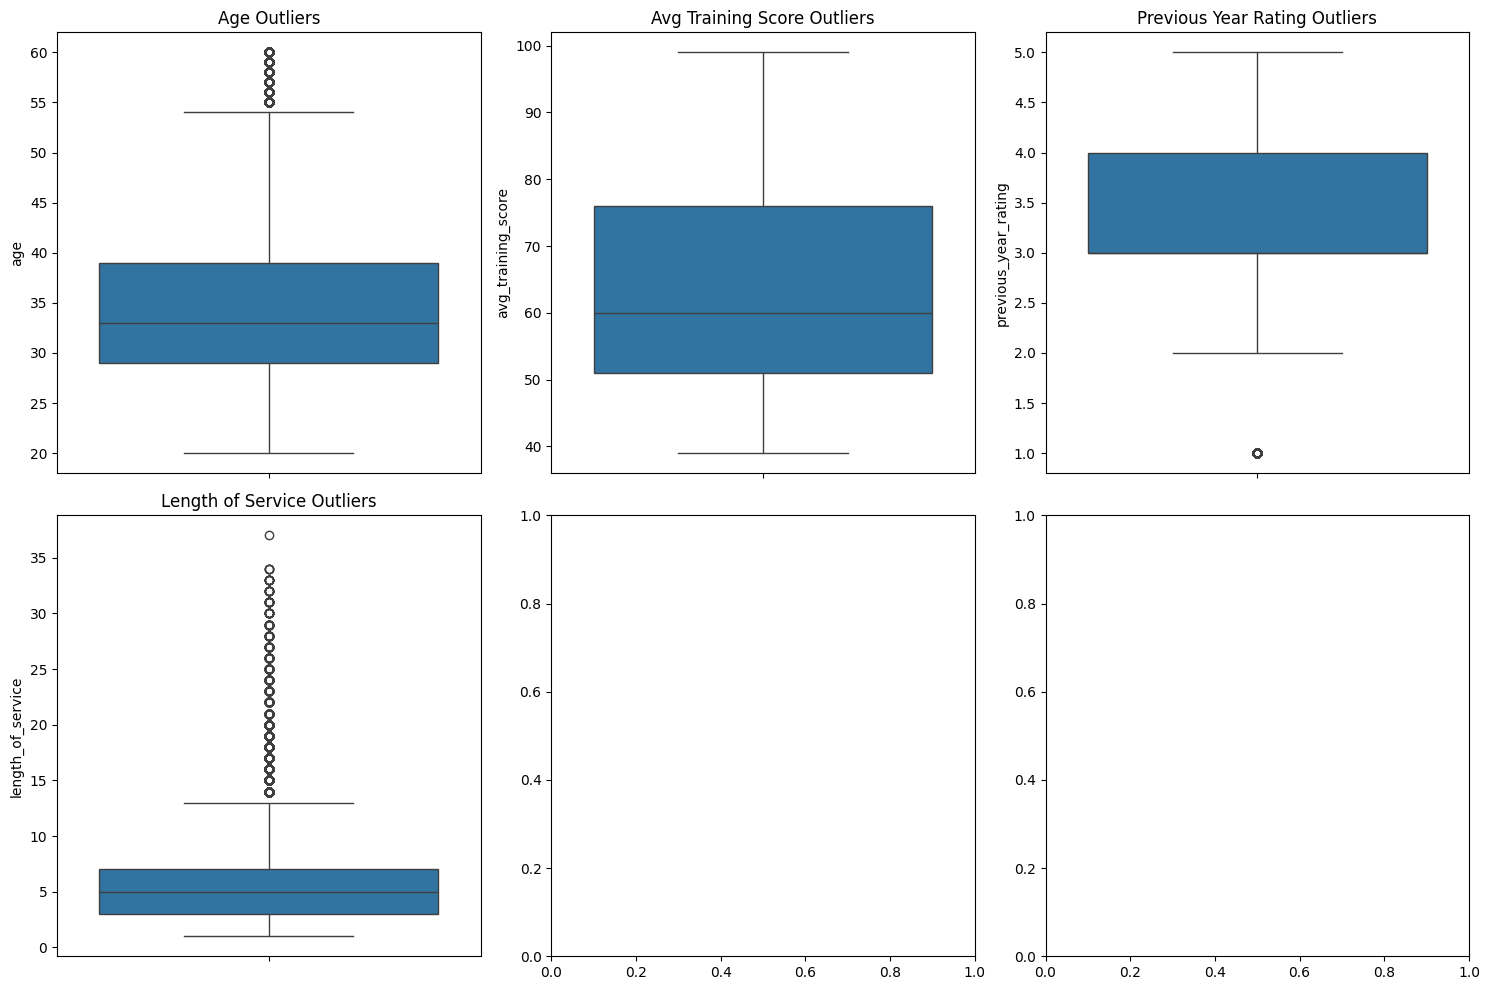

In [28]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Age
sns.boxplot(y=df['age'], ax=axes[0,0])
axes[0,0].set_title('Age Outliers')

# avg_training_score
sns.boxplot(y=df['avg_training_score'], ax=axes[0,1])
axes[0,1].set_title('Avg Training Score Outliers')

# previous_year_rating
sns.boxplot(y=df['previous_year_rating'], ax=axes[0,2])
axes[0,2].set_title('Previous Year Rating Outliers')

# length_of_service
sns.boxplot(y=df['length_of_service'], ax=axes[1,0])
axes[1,0].set_title('Length of Service Outliers')


plt.tight_layout()
plt.show()

## Outlier Analysis Observations

### Age
- Most employees are between 29 to 39 years old
- There are a few outliers above 55 years
- These are senior employees who are very few 
  in number but still part of the company
- Outliers are not extreme so we can keep them as is

### Avg Training Score
- Scores are well spread between 50 to 80
- No major outliers visible
- This is the cleanest column with no outlier problem

### Previous Year Rating
- Ratings are between 1 to 5 (discrete values)
- Only one outlier visible at the bottom (rating = 1)
- Very few employees have extremely poor rating
- Not a major concern

### Length of Service
- Most employees have 5 years or less of service
- But there are MANY outliers going up to 35+ years
- This is the most problematic column for outliers
- A large number of dots visible above the box
- These are very senior long-serving employees
- We may need to handle these during preprocessing

### Overall Takeaway
- **Length of Service** has the most outliers 
  and needs attention during preprocessing
- **No of Trainings** also has notable outliers
- **Age** has a few outliers but not concerning
- **Avg Training Score** is the cleanest column


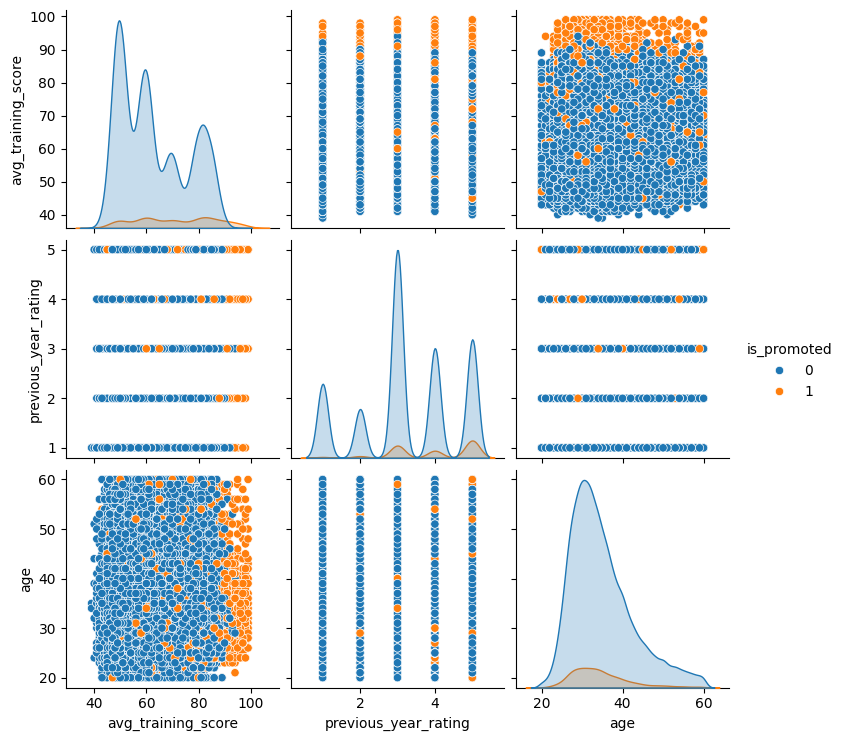

In [29]:
sns.pairplot(df[['avg_training_score', 
                  'previous_year_rating',
                  'age', 'is_promoted']], 
                  hue='is_promoted')

## Pair Plot Observations


### Avg Training Score 
- Promoted employees (orange) are clearly shifted 
  towards higher training scores (80-100)
- Non promoted employees (blue) are more spread 
  across lower scores (40-70)
- This confirms training score is a strong 
  predictor of promotion

### Previous Year Rating
- Both promoted and non promoted employees 
  have similar rating distributions
- But promoted employees (orange) appear 
  slightly more at rating 4 and 5
- Rating 3 has the most non promoted employees

### Age
- Both promoted and non promoted employees 
  have almost identical age distribution
- Orange and blue curves overlap completely
- This confirms age has NO impact on promotion

### Avg Training Score vs Previous Year Rating
- Promoted employees (orange) tend to cluster 
  at HIGH training score AND HIGH rating together


### Avg Training Score vs Age
- Promoted employees (orange) are spread across 
  all age groups but with higher training scores
- Age does not matter — a young employee with 
  high training score has equal chance as 
  an older employee

### Overall Takeaway
- Promoted employees clearly stand out in 
  avg_training_score
- Age is completely irrelevant for promotion


## Final EDA Conclusion

### What We Found
- Only 8.5% employees get promoted — 
  dataset is imbalanced, need SMOTE

### Top 3 Factors for Promotion
- High avg training score
- Winning an award (44% promotion rate!)
- Good previous year rating

### Things That Don't Matter
- Age and length of service have 
  almost zero impact on promotion

### Data Issues to Fix in Preprocessing
- Missing values in education and 
  previous_year_rating
- Encode categorical columns
- Drop employee_id

### Next Step
- Move to Preprocessing and then 
  build Random Forest or XGBoost model